In [1]:
from py_files.setup import *
setup_notebook()

# 1. `Industry use decomposition`

*Run full time series with GDP normalization*

In [2]:
investment_timeseries = il.load_or_compute_timeseries(years=range(1966, 2025))

Loading timeseries from 0_intermediate/direct_NX_cache/timeseries_1966_2024.parquet …


*plot*

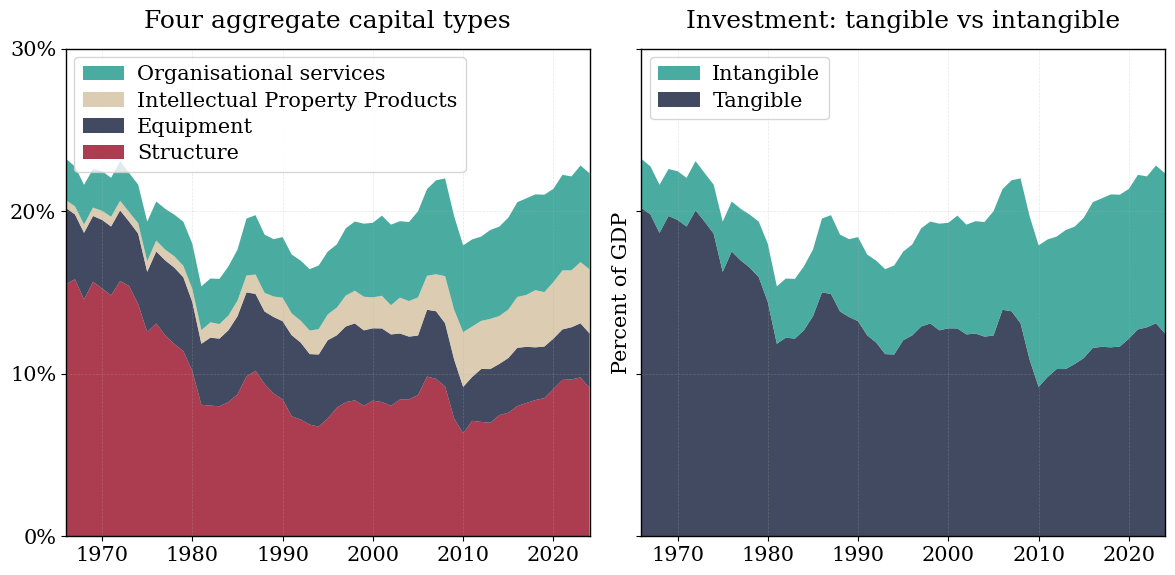

In [3]:
il.plot_investment_composition(
    investment_timeseries, 
    as_pct_gdp=True
)

In [4]:
# Check the results
print("\nInvestment as % of GDP:")
print(investment_timeseries[
    ['structures', 'equipment', 'intellectual_property', 'organizational']]
)


Investment as % of GDP:
      structures  equipment  intellectual_property  organizational
year                                                              
1966   15.522635   4.683209               0.481688        2.539272
1967   15.815563   3.991063               0.500456        2.455955
1968   14.575013   4.098546               0.516465        2.443349
1969   15.663789   4.048478               0.517650        2.373782
1970   15.252908   4.217948               0.559838        2.436463
1971   14.823905   4.241411               0.602625        2.393689
1972   15.715909   4.340559               0.591334        2.439921
1973   15.400151   3.964301               0.588001        2.401838
1974   14.286388   4.340123               0.637807        2.379564
1975   12.572633   3.700241               0.659726        2.428802
1976   13.101292   4.427072               0.673049        2.403690
1977   12.366143   4.607774               0.663117        2.512865
1978   11.831671   4.702937          

In [5]:
# result = il.compute_direct_for_year(2024)
result = il.load_or_compute_year(2024)

use_shares = result['use_shares']

gdp = il.fetch_gdp_data([2017]).iloc[0]

table = (use_shares[['C_share', 'I_share', 'X_share']]
         .rename(columns={
             'C_share': 'C (%)',
             'I_share': 'I (%)',
             'X_share': 'X (%)'
         })
         .round(1))

table.insert(0, 'Uses/GDP', (use_shares['output'] / gdp * 100).round(1))
table.head(60)

  Loading year 2024 from cache …


,Uses/GDP,C (%),I (%),X (%)
01000,3.9,21.6,0.5,77.9
02000,0.2,42.7,0.5,56.8
03000,0.2,3.6,0.0,96.4
06090,1.2,2.0,3.0,95.0
10120,9.3,24.3,1.1,74.6
13150,0.5,14.5,3.2,82.3
16000,0.6,8.5,4.7,86.8
17000,0.4,4.8,0.7,94.5
18000,0.3,2.3,2.4,95.3
19000,1.7,38.1,0.0,61.8
